In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\shaun\Downloads\archive.zip")




df.replace('?', pd.NA, inplace=True)

for col in df.columns:
    if df[col].dtype == 'object':
       
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        
        df[col].fillna(df[col].median(), inplace=True)


df.drop_duplicates(inplace=True)


print(df.isna().sum())

for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print(df.isna().sum())

C:\Users\shaun\AppData\Local\Temp\ipykernel_23540\4261934255.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\shaun\AppData\Local\Temp\ipykernel_23540\4261934255.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


C:\Users\shaun\AppData\Local\Temp\ipykernel_23540\4261934255.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\shaun\AppData\Local\Temp\ipykernel_23540\4261934255.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [ ]:

df.drop_duplicates(inplace=True)

df = df[df['age'] > 0]

print(df.shape)


C:\Users\shaun\AppData\Local\Temp\ipykernel_23540\3722852485.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\shaun\AppData\Local\Temp\ipykernel_23540\3722852485.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

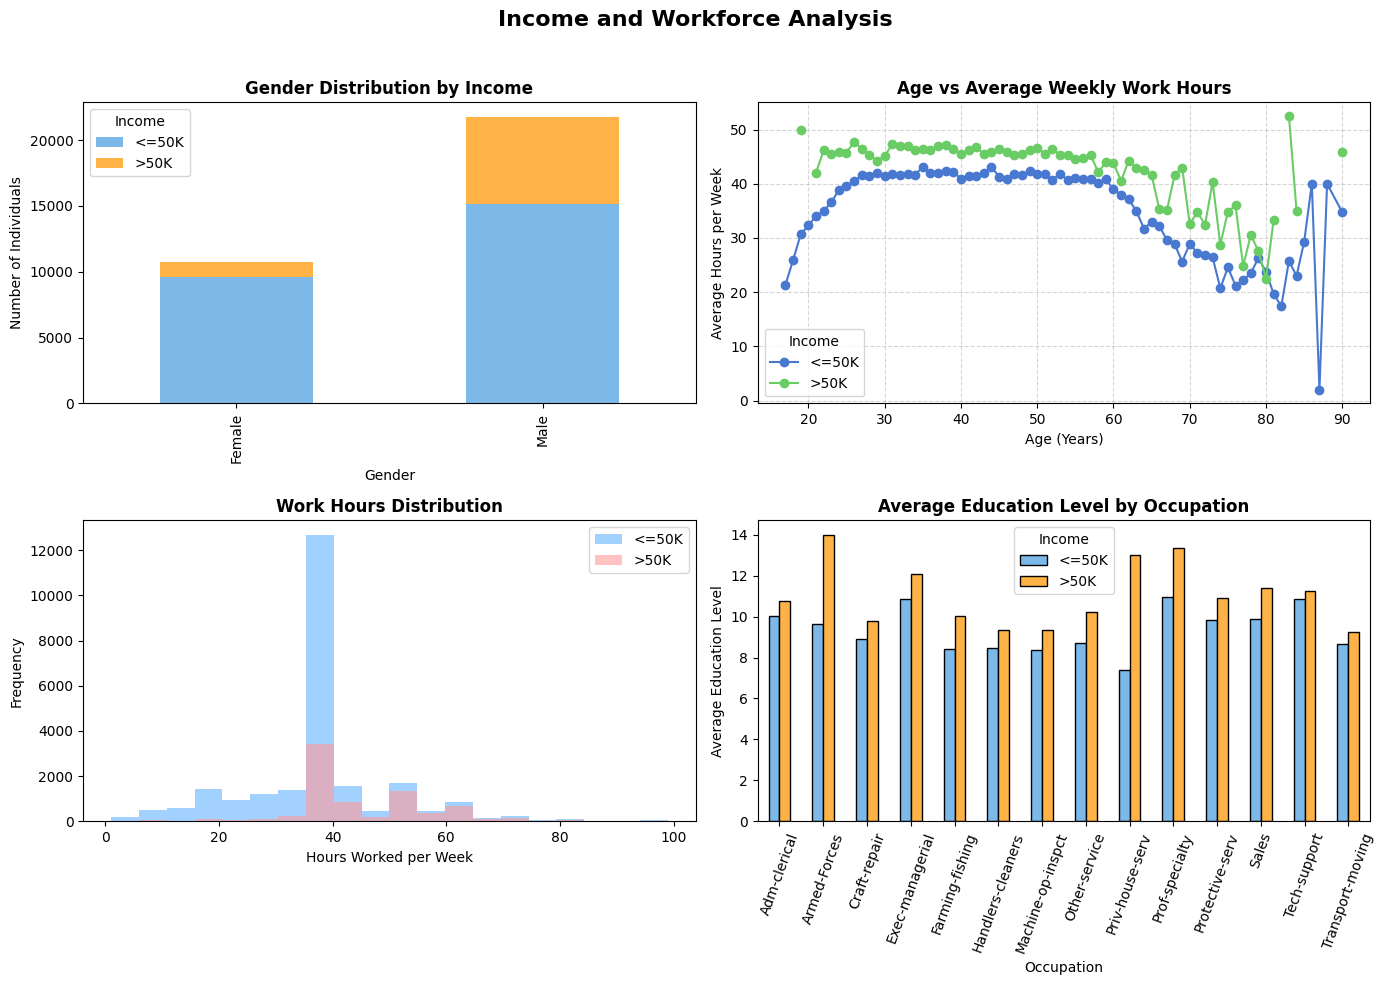

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df.replace('?', pd.NA, inplace=True)


for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

df.drop_duplicates(inplace=True)


fig, ax = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Income and Workforce Analysis', fontsize=16, fontweight='bold')

df.groupby(['sex', 'income']).size().unstack().plot(
    kind='bar', stacked=True, ax=ax[0,0], color=['#7cb9e8','#ffb347']
)
ax[0,0].set_title('Gender Distribution by Income', fontsize=12, fontweight='bold')
ax[0,0].set_xlabel('Gender')
ax[0,0].set_ylabel('Number of Individuals')
ax[0,0].legend(title='Income')

df.groupby(['age', 'income'])['hours.per.week'].mean().unstack().plot(
    ax=ax[0,1], marker='o', linewidth=1.5
)
ax[0,1].set_title('Age vs Average Weekly Work Hours', fontsize=12, fontweight='bold')
ax[0,1].set_xlabel('Age (Years)')
ax[0,1].set_ylabel('Average Hours per Week')
ax[0,1].legend(title='Income')
ax[0,1].grid(True, linestyle='--', alpha=0.5)

for inc, color in zip(['<=50K', '>50K'], ['#66b3ff','#ff9999']):
    ax[1,0].hist(df[df['income']==inc]['hours.per.week'], bins=20, alpha=0.6, label=inc, color=color)
ax[1,0].set_title('Work Hours Distribution', fontsize=12, fontweight='bold')
ax[1,0].set_xlabel('Hours Worked per Week')
ax[1,0].set_ylabel('Frequency')
ax[1,0].legend()

df.groupby(['occupation', 'income'])['education.num'].mean().unstack().plot(
    kind='bar', ax=ax[1,1], color=['#7cb9e8','#ffb347'], edgecolor='black'
)
ax[1,1].set_title('Average Education Level by Occupation', fontsize=12, fontweight='bold')
ax[1,1].set_xlabel('Occupation')
ax[1,1].set_ylabel('Average Education Level')
ax[1,1].legend(title='Income')
ax[1,1].tick_params(axis='x', rotation=70)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()
